## Second Order ODE using Euler’s Method, Analyzing Stability

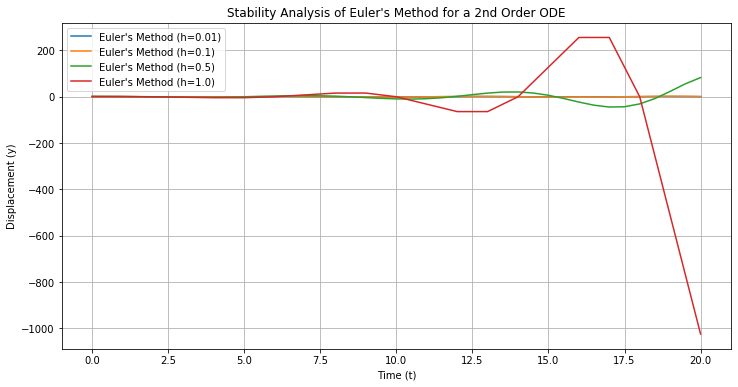

In [2]:
import numpy as np
import matplotlib.pyplot as plt
# Parameters
k = 1.0        # Spring constant
h_values = [0.01, 0.1, 0.5, 1.0]  # Different step sizes to test stability
t_start = 0    # Start time
t_end = 20     # End time
y_0 = 1.0      # Initial displacement
v_0 = 0.0      # Initial velocity
# Function to apply Euler's Method for given step size
def euler_method(h, k, t_start, t_end, y_0, v_0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))    
    # Set initial conditions
    y_values[0] = y_0
    v_values[0] = v_0

    for i in range(1, len(t_values)):
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]        
        # Update equations for Euler's Method
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k * y_n)   
    return t_values, y_values
# Plot results for different step sizes
plt.figure(figsize=(12, 6))

for h in h_values:
    t, y = euler_method(h, k, t_start, t_end, y_0, v_0)
    plt.plot(t, y, label=f'Euler\'s Method (h={h})')
plt.xlabel('Time (t)')
plt.ylabel('Displacement (y)')
plt.title('Stability Analysis of Euler\'s Method for a 2nd Order ODE')
plt.legend()
plt.grid(True)
plt.show()

## First Order ODE Example w/ Runge Kutta (RK4):

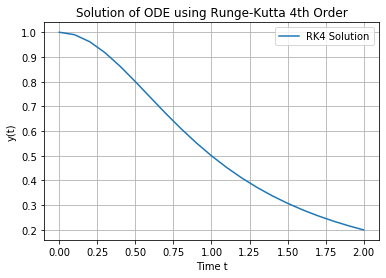

In [3]:
# Define the ODE function, for example, dy/dt = f(t, y) = -2 * t * y^2
def f(t, y):
    return -2 * t * y**2
# Implement the RK4 method
def runge_kutta_4(f, y0, t0, tf, h):
    # Create an array for time steps
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros(len(t_values))    
    # Set the initial condition
    y_values[0] = y0
    # Perform the RK4 iteration
    for i in range(1, len(t_values)):
        t = t_values[i - 1]
        y = y_values[i - 1]        
        k1 = h * f(t, y)
        k2 = h * f(t + h / 2, y + k1 / 2)
        k3 = h * f(t + h / 2, y + k2 / 2)
        k4 = h * f(t + h, y + k3)        
        # Update y based on the RK4 formula
        y_values[i] = y + (k1 + 2 * k2 + 2 * k3 + k4) / 6
    return t_values, y_values
# Set initial conditions and parameters
y0 = 1.0  # Initial value of y
t0 = 0.0  # Initial time
tf = 2.0  # Final time
h = 0.1   # Step size
# Run the RK4 solver
t_values, y_values = runge_kutta_4(f, y0, t0, tf, h)
# Plot the results
plt.plot(t_values, y_values, label='RK4 Solution')
plt.xlabel('Time t')
plt.ylabel('y(t)')
plt.title('Solution of ODE using Runge-Kutta 4th Order')
plt.legend()
plt.grid(True)
plt.show()

## First Order ODE Example w/ Runge Kutta (RK4) - Stability Region:

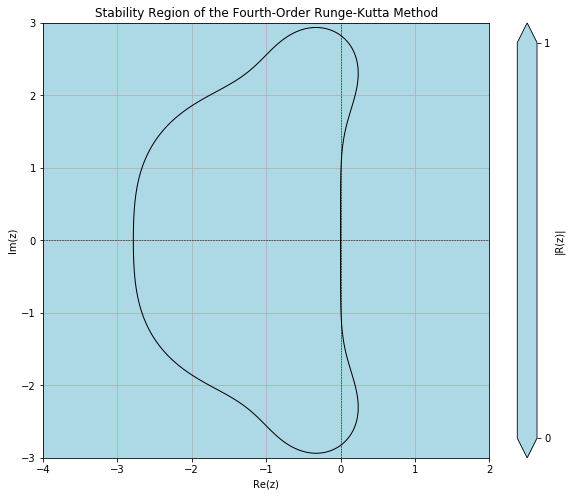

In [4]:
# Define the RK4 stability function
def rk4_stability_function(z):
    return 1 + z + (z**2) / 2 + (z**3) / 6 + (z**4) / 24
# Generate a grid of complex numbers (z) in the complex plane
real_vals = np.linspace(-4, 2, 500)  # Adjust range for visualization
imag_vals = np.linspace(-3, 3, 500)
real, imag = np.meshgrid(real_vals, imag_vals)
z = real + 1j * imag
# Calculate the magnitude of the stability function
R = rk4_stability_function(z)
magnitude = np.abs(R)

# Plot the stability region where |R(z)| <= 1
plt.figure(figsize=(10, 8))
plt.contourf(real, imag, magnitude, levels=[0, 1],
colors=['lightblue'], extend='both')
plt.colorbar(label='|R(z)|')
plt.contour(real, imag, magnitude, levels=[1], colors='black', linewidths=1)
# Plot aesthetics
plt.title('Stability Region of the Fourth-Order Runge-Kutta Method')

plt.xlabel('Re(z)')
plt.ylabel('Im(z)')
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.show()